In [1]:
import sys, os

import numpy as np
# Note that the path ./Albedo_project/data_processing is now in the path
import xarray as xr
from cloudpathlib import AnyPath
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Local Imports
curdir = os.getcwd()
print(curdir+"../data_processing")
sys.path.insert(0, curdir+"/../data_processing")
sys.path.insert(0, curdir+"/../visualization")
import ceres_ebaf
import ceres_ebaf_plotting

fig_path = AnyPath("../../Figs")
current_month_folder="23Aug"
base_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")

color_ocean = "blue"
color_land = "green"

/Users/mawa7160/Library/CloudStorage/OneDrive-UCB-O365/Documents/GitHub/Hemispheric-Albedo-Project/Albedo_project/Notebooks../data_processing


In [2]:
run_len = 0

ebaf_4_2_file_path = base_path / current_month_folder / "CERES_EBAF-TOA_Ed4.2_Subset_200003-202305.nc"
ebaf_4_2_full_years = xr.open_dataset(ebaf_4_2_file_path)

# Getting Version 4.2
solar_in_4_2 = ceres_ebaf.create_hemisphere_data(ebaf_4_2_full_years["solar_mon"], running_length=run_len)
shortwave_all_sky_4_2 = ceres_ebaf.create_hemisphere_data(ebaf_4_2_full_years["toa_sw_all_mon"], running_length=run_len)
shortwave_clear_sky_4_2 = ceres_ebaf.create_hemisphere_data(ebaf_4_2_full_years["toa_sw_clr_c_mon"], running_length=run_len)
cre_total_4_2 = shortwave_all_sky_4_2-shortwave_clear_sky_4_2

mask_data_SSF1d = xr.open_dataset("/Users/mawa7160/dev/data/CERES/CERES_SSF1deg-Day_NOAA20-VIIRS_Ed1B_Subset_20230501-20230531.nc")
one_day = mask_data_SSF1d.sel(time=slice("2023-05-01"))
one_day_ocean_coverage = one_day["aux_ocean_daily"]
one_day_snow_coverage = one_day["aux_snow_daily"]

ocean_mask = ((one_day_ocean_coverage>75)[0]).astype(int)

In [3]:
shortwave_all_sky_ocean_masked = ceres_ebaf.create_hemisphere_data(ebaf_4_2_full_years["toa_sw_all_mon"],
                                                                   time_weighting=1,end_yr="2023",
                                                                   use_mask=True, masked_name="ocean",
                                                                   mask_data=ocean_mask, unmasked_name="land")
shortwave_clear_sky_ocean_masked = ceres_ebaf.create_hemisphere_data(ebaf_4_2_full_years["toa_sw_clr_c_mon"],
                                                                    time_weighting=1, end_yr="2023",
                                                                   use_mask=True, masked_name="ocean",
                                                                   mask_data=ocean_mask, unmasked_name="land")
cre_ocean_masked = shortwave_all_sky_ocean_masked - shortwave_clear_sky_ocean_masked

cre_diff = cre_ocean_masked["nh"]-cre_ocean_masked["sh"]
clear_sky_diff = shortwave_clear_sky_ocean_masked["nh"]-shortwave_clear_sky_ocean_masked["sh"]
all_sky_diff = shortwave_all_sky_ocean_masked["nh"]-shortwave_all_sky_ocean_masked["sh"]

sw_all_hemi_ocean_diff = shortwave_all_sky_ocean_masked["nh_ocean"] - shortwave_all_sky_ocean_masked["sh_ocean"]
sw_all_hemi_land_diff = shortwave_all_sky_ocean_masked["nh_land"] - shortwave_all_sky_ocean_masked["sh_land"]

sw_clear_hemi_ocean_diff = shortwave_clear_sky_ocean_masked["nh_ocean"] - shortwave_clear_sky_ocean_masked["sh_ocean"]
sw_clear_hemi_land_diff = shortwave_clear_sky_ocean_masked["nh_land"] - shortwave_clear_sky_ocean_masked["sh_land"]

sw_cre_hemi_ocean_diff = cre_ocean_masked["nh_ocean"] - cre_ocean_masked["sh_ocean"]
sw_cre_hemi_land_diff = cre_ocean_masked["nh_land"] - cre_ocean_masked["sh_land"]

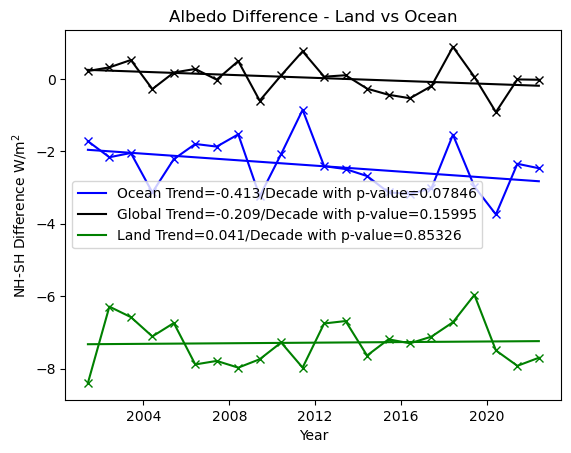

In [4]:
# Plotting the all sky difference in SW
ceres_ebaf_plotting.plot_monthly_data_with_reg_line(sw_all_hemi_ocean_diff.time, sw_all_hemi_ocean_diff,
                                            include_trends=True, tick_color=color_ocean, label="Ocean")
ceres_ebaf_plotting.plot_monthly_data_with_reg_line(all_sky_diff.time, all_sky_diff, include_trends=True,
                                            tick_color="k", label="Global")
ceres_ebaf_plotting.plot_monthly_data_with_reg_line(sw_all_hemi_land_diff.time, sw_all_hemi_land_diff, include_trends=True,
                                            y_label="NH-SH Difference W/m$^2$", tick_color=color_land, label="Land",
                                            title="Albedo Difference - Land vs Ocean")

plt.savefig(fig_path / current_month_folder / "All-Sky-Difference-Land-Ocean")

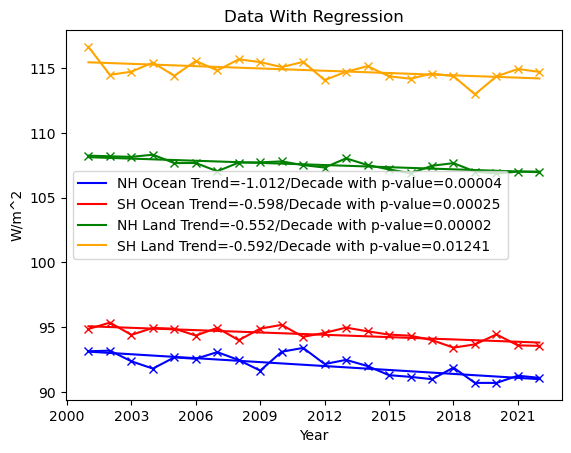

In [5]:

# Plotting the all sky difference in SW
ceres_ebaf_plotting.plot_yearly_data_with_reg_line(shortwave_all_sky_ocean_masked["nh_ocean"].year, shortwave_all_sky_ocean_masked["nh_ocean"],
                                            include_trends=True, tick_color=color_ocean, label="NH Ocean")
ceres_ebaf_plotting.plot_yearly_data_with_reg_line(shortwave_all_sky_ocean_masked["sh_ocean"].year, shortwave_all_sky_ocean_masked["sh_ocean"],
                                                    include_trends=True,tick_color="red", label="SH Ocean")

# Plotting the all sky difference in SW
ceres_ebaf_plotting.plot_yearly_data_with_reg_line(shortwave_all_sky_ocean_masked["nh_land"].year, shortwave_all_sky_ocean_masked["nh_land"],
                                            include_trends=True, tick_color="green", label="NH Land")
ceres_ebaf_plotting.plot_yearly_data_with_reg_line(shortwave_all_sky_ocean_masked["sh_land"].year, shortwave_all_sky_ocean_masked["sh_land"],
                                                    include_trends=True, tick_color="orange", label=f"SH Land")